In [23]:
import numpy as np
import pandas as pd
import glob
import os
import sys
import matplotlib.pyplot as plt
import torch
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


(159, 256, 256)


In [21]:
def plot_brain_2(filepath): #plot with shape zyx 126*256*256
    filename = os.path.basename(filepath)
    dose = np.load(filepath)
    VOXELNUMBER_X = 256
    VOXELNUMBER_Y = 256
    VOXELNUMBER_Z = 159

    DELTA_Z = 2.5
    DELTA_X = 0.759766*2
    DELTA_Y = DELTA_X

    x_vals = np.arange(-194.5 , 194.5 , DELTA_X)
    x_vals = x_vals + DELTA_X/2

    y_vals = np.arange(-194.5 , 194.5 , DELTA_Y)
    y_vals = y_vals + DELTA_Y/2

    z_vals = np.arange(-271 , 126.5, DELTA_Z) 
    z_vals = z_vals + DELTA_Z/2

    max_index = np.unravel_index(dose.argmax(), dose.shape)


    dose_x = []
    dose_y = []
    dose_z = []
    for x in range(VOXELNUMBER_X):
        dose_x.append(dose[int(max_index[0]), int(max_index[1]),x])        
    for y in range(VOXELNUMBER_Y):
        dose_y.append(dose[int(max_index[0]),y,int(max_index[2])])
    for z in range(VOXELNUMBER_Z):        
        dose_z.append(dose[z, int(max_index[1]),int(max_index[2])])

    # Create a 2x3 grid of subplots

    fig = plt.figure(figsize=(8, 3))
    gs = gridspec.GridSpec(1, 3, width_ratios=[0.7, 0.7, 1])  # 3 plots
    ax2 = plt.subplot(gs[2])
    ax2.plot(x_vals, dose_x)
    ax2.set_yscale('linear')
    ax2.set_xlabel('X [mm] (Beam direction)')
    #ax2.set_ylabel('Dose [Gy]')

    #axs[2].set_title('Dose Distribution in water along X direction')

    ax1 = plt.subplot(gs[1])
    ax1.plot(y_vals, dose_y)
    ax1.set_yscale('linear')
    ax1.set_xlabel('Y [mm]')
    #ax1.set_ylabel('Dose [Gy]')
    #axs[1].set_title('Dose Distribution in water along Y direction')

    ax0 = plt.subplot(gs[0])
    ax0.plot(z_vals, dose_z)
    ax0.set_yscale('linear')
    ax0.set_xlabel('Z [mm]')
    ax0.set_ylabel('Dose [Gy]')
    ax0.set_title('Dose in head phantom at beam center : ('+ filename +')')
    #axs[0].set_title('Dose Distribution in water along Z direction')

    
    plt.tight_layout()
    plt.show()  

(159, 256, 256)


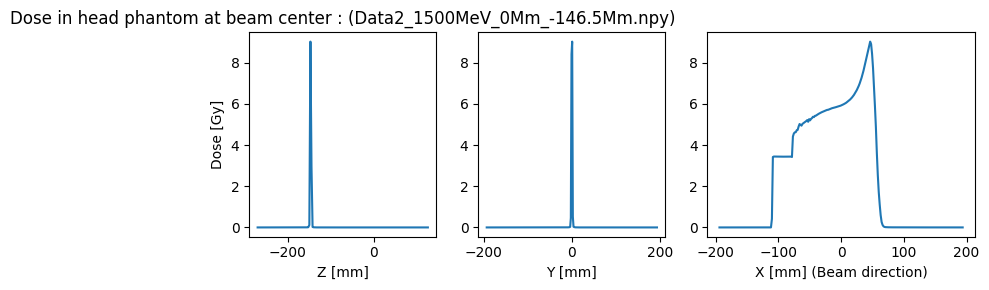

In [25]:
data_folder = "/scratch/tappay01/data/data2"

filename ='Data2_1500MeV_0Mm_-146.5Mm.npy'
filepath = os.path.join(data_folder, filename)
dosemap = np.load(os.path.join(data_folder, filename))
print(dosemap.shape)
y,z = float(filename.split('_')[2][:-2]),float(filename.split('_')[3][:-6]) # Example y=0 and z=-121.5

plot_brain_2(filepath)